In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


In [6]:
df = pd.read_csv('Iris.csv', usecols=['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm','Species'])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
# encode labels
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

In [48]:
#X = df[['PetalWidthCm','PetalLengthCm']].values
#y = df['Species']

X = df[['SepalWidthCm','SepalLengthCm']].values
y = df['Species']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

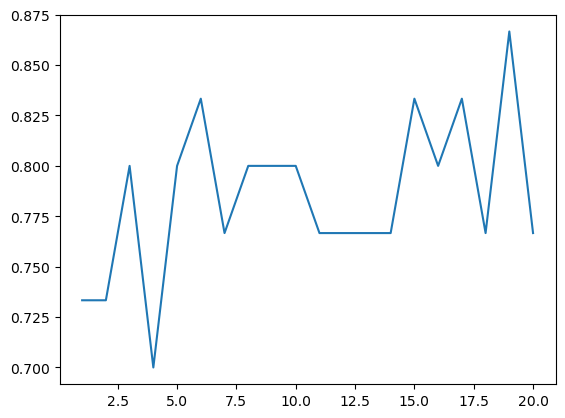

In [50]:
# to select K
scores = []

for i in range (1,21):
    knn= KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    y_pred = knn.predict(X_test)
    scores.append(accuracy_score(y_test,y_pred))
 
plt.plot(range(1,21),scores)

In [57]:
knn = KNeighborsClassifier(n_neighbors=19)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=19)

In [58]:
y_pred = knn.predict(X_test)

In [59]:
accuracy_score(y_test, y_pred)

0.8666666666666667

In [60]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        10\n           1       1.00      0.56      0.71         9\n           2       0.73      1.00      0.85        11\n\n    accuracy                           0.87        30\n   macro avg       0.91      0.85      0.85        30\nweighted avg       0.90      0.87      0.86        30\n'

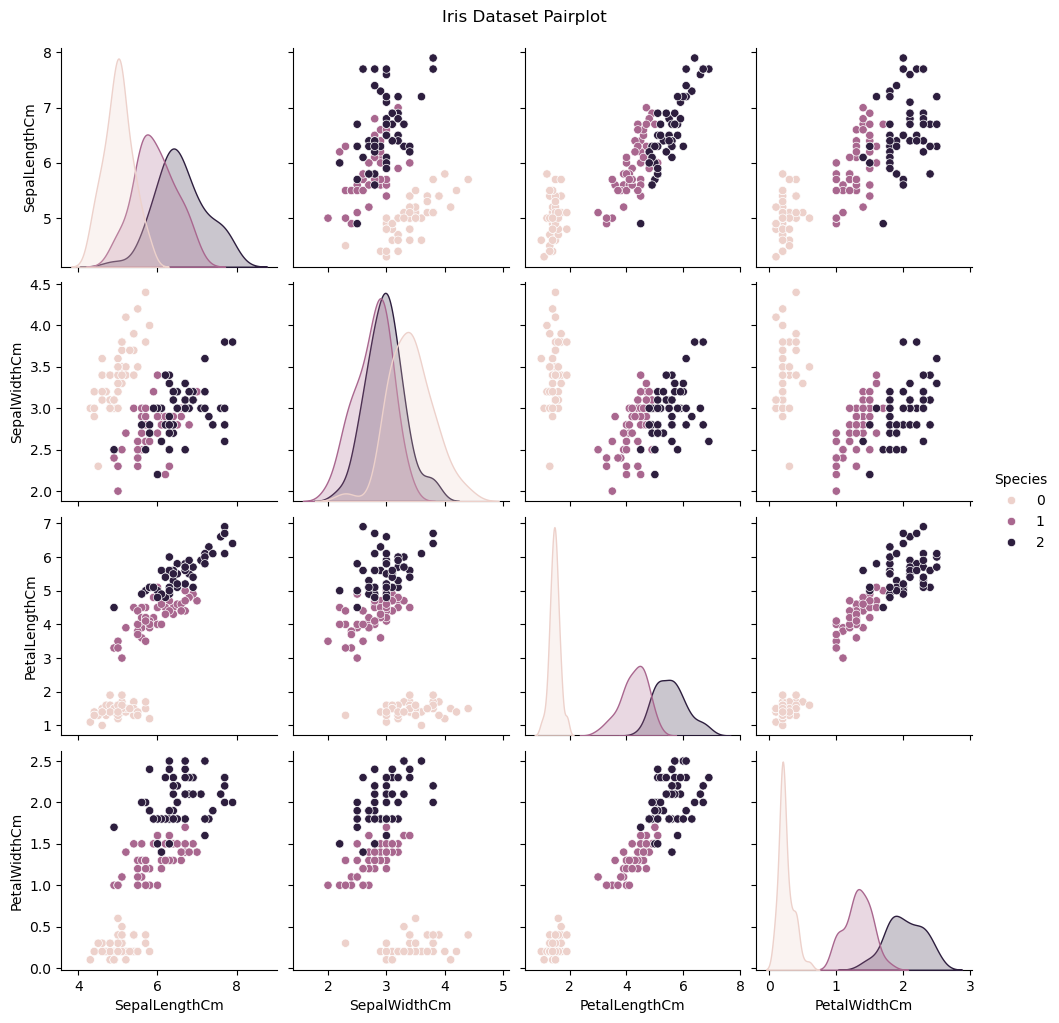

In [61]:
import seaborn as sns

sns.pairplot(df, hue = 'Species')
plt.suptitle("Iris Dataset Pairplot", y=1.02)
plt.show()